### Exploratory Time-Series Analysis of UK 10-Year Gilt Yields

This notebook is the second stage of the gilt-yield time-series project.

The objective is to determine how the statistical behaviour of the **yield level** differs from the behaviour of **daily yield changes**, before any conditional-mean forecasting model is fitted.

The analysis is deliberately restricted to:

1. yield level versus first differences;
2. visual stationarity diagnostics;
3. Augmented Dickey-Fuller (ADF) tests;
4. KPSS stationarity tests;
5. autocorrelation (ACF) and partial autocorrelation (PACF);
6. structural-break and crisis-date diagnostics.

### Import packages

Only diagnostic and statistical-test functions are imported. No forecasting model classes are needed in this notebook.

In [13]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss, zivot_andrews
from statsmodels.tools.sm_exceptions import InterpolationWarning
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

%matplotlib inline

### Data dependency

The preferred input is the cleaned dataset produced by Notebook `01. The Processed BoE data`

This keeps the project modular: 
- Notebook 01 handles data validation and cleaning, while this notebook handles time-series diagnostics.

A minimal raw-data fallback is included so that the notebook remains runnable while the processed-data pipeline is being finalised. The fallback reproduces only the basic column selection and cleaning rules already established in Notebook 01.

In [14]:
PROCESSED_FILENAME = "boe_10y_zero_coupon_clean.csv"
RAW_FILENAME = "Bank of England Database.csv"

processed_candidates = [
    Path("data/processed") / PROCESSED_FILENAME,
    Path("../data/processed") / PROCESSED_FILENAME,
]

raw_candidates = [
    Path("data/raw") / RAW_FILENAME,
    Path("../data/raw") / RAW_FILENAME,
    Path.home() / "Downloads" / "Dissertation" / RAW_FILENAME,
]

processed_path = next(
    (path for path in processed_candidates if path.exists()),
    None
)

raw_path = next(
    (path for path in raw_candidates if path.exists()),
    None
)

print("Processed file found:", processed_path)
print("Raw fallback found:   ", raw_path)

Processed file found: data/processed/boe_10y_zero_coupon_clean.csv
Raw fallback found:    /Users/qp252008/Downloads/Dissertation/Bank of England Database.csv


In [15]:
if processed_path is not None:
    boe = pd.read_csv(processed_path)
    print(f"Loaded processed data from: {processed_path}")

elif raw_path is not None:
    print(
        "Processed dataset not found. "
        "Using the raw-data fallback established from Notebook 01."
    )

    raw = pd.read_csv(raw_path)

    required_raw_columns = {"DATE", "IUDMNZC"}
    missing_raw_columns = required_raw_columns.difference(raw.columns)

    if missing_raw_columns:
        raise ValueError(
            "Raw BoE file does not contain the expected columns: "
            f"{sorted(missing_raw_columns)}"
        )

    boe = raw[["DATE", "IUDMNZC"]].rename(
        columns={
            "DATE": "date",
            "IUDMNZC": "yield_10y",
        }
    )

    date_text = boe["date"].astype(str).str.strip()

    # First try the ISO format used in the current BoE file.
    parsed_dates = pd.to_datetime(
        date_text,
        format="%Y-%m-%d",
        errors="coerce"
    )

    # Fall back to day-first parsing only for values not parsed above.
    if parsed_dates.isna().any():
        fallback_dates = pd.to_datetime(
            date_text,
            dayfirst=True,
            errors="coerce"
        )
        parsed_dates = parsed_dates.fillna(fallback_dates)

    boe["date"] = parsed_dates
    boe["yield_10y"] = pd.to_numeric(
        boe["yield_10y"],
        errors="coerce"
    )

    boe = (
        boe
        .dropna(subset=["date", "yield_10y"])
        .sort_values("date")
        .drop_duplicates(subset="date", keep="first")
        .reset_index(drop=True)
    )

else:
    raise FileNotFoundError(
        "Neither the processed dataset nor the raw BoE CSV was found.\n\n"
        "Preferred project path:\n"
        "  data/processed/boe_10y_zero_coupon_clean.csv\n\n"
        "Run Notebook 01 first and save its cleaned dataset before continuing."
    )

Loaded processed data from: data/processed/boe_10y_zero_coupon_clean.csv


### Validate the working dataset

The analysis requires one unique date column and one numeric 10-year yield column.

The observations are market/business-day observations. Therefore, a lag of one observation means the **previous available BoE market observation**, not necessarily the previous calendar day.

In [16]:
required_columns = {"date", "yield_10y"}
missing_columns = required_columns.difference(boe.columns)

if missing_columns:
    raise ValueError(
        f"Missing required columns: {sorted(missing_columns)}"
    )

boe["date"] = pd.to_datetime(boe["date"], errors="coerce")
boe["yield_10y"] = pd.to_numeric(boe["yield_10y"], errors="coerce")

boe = (
    boe
    .dropna(subset=["date", "yield_10y"])
    .sort_values("date")
    .drop_duplicates(subset="date", keep="first")
    .reset_index(drop=True)
)

if not boe["date"].is_monotonic_increasing:
    raise ValueError("Dates are not in chronological order.")

if boe["date"].duplicated().any():
    raise ValueError("Duplicate dates remain in the working dataset.")

print("Observations:", len(boe))
print("Start date:  ", boe["date"].min().date())
print("End date:    ", boe["date"].max().date())
print("Missing yields:", int(boe["yield_10y"].isna().sum()))

boe.head()

Observations: 2779
Start date:   2014-01-02
End date:     2024-12-31
Missing yields: 0


,date,yield_10y,date_raw,yield_raw
0,2014-01-02,3.1625,02 Jan 14,3.1625
1,2014-01-03,3.1579,03 Jan 14,3.1579
2,2014-01-06,3.1053,06 Jan 14,3.1053
3,2014-01-07,3.0831,07 Jan 14,3.0831
4,2014-01-08,3.1140,08 Jan 14,3.1140


#### Data validation

- The processed dataset contains 2,779 daily observations of the Bank of England
10-year nominal zero-coupon government bond yield between January 2014 and
December 2024. 

- No yield observations are missing after cleaning. The original
date and yield fields have also been retained to preserve traceability to the
raw Bank of England dataset.

- The dataset is ready for exploratory time-series analysis.

### Construct the first-difference series

Let $y_t$ denote the 10-year yield level in percentage points.

The first difference is

$$
\Delta y_t = y_t - y_{t-1}.
$$

The same movement is expressed in basis points as

$$
\Delta y_t^{bps} = 100\,\Delta y_t,
$$

because one basis point is $0.01$ percentage points.

Differencing is used here to examine whether the long-run movement in the yield level is removed. No claim about a Random Walk or any AR/MA structure is made at this stage.

In [17]:
boe["yield_change"] = boe["yield_10y"].diff()
boe["yield_change_bps"] = 100 * boe["yield_change"]

analysis_data = boe[
    ["date", "yield_10y", "yield_change", "yield_change_bps"]
].copy()

analysis_data.head()

,date,yield_10y,yield_change,yield_change_bps
0,2014-01-02,3.1625,NaN,NaN
1,2014-01-03,3.1579,-0.0046,-0.46
2,2014-01-06,3.1053,-0.0526,-5.26
3,2014-01-07,3.0831,-0.0222,-2.22
4,2014-01-08,3.1140,0.0309,3.09


## Part I: Yield level versus yield changes

### Compare both series visually

A stationary series should have statistical behaviour that is broadly stable through time. A first visual check therefore asks whether the mean and spread appear to remain in a similar range.

Visual inspection is not a formal stationarity test.

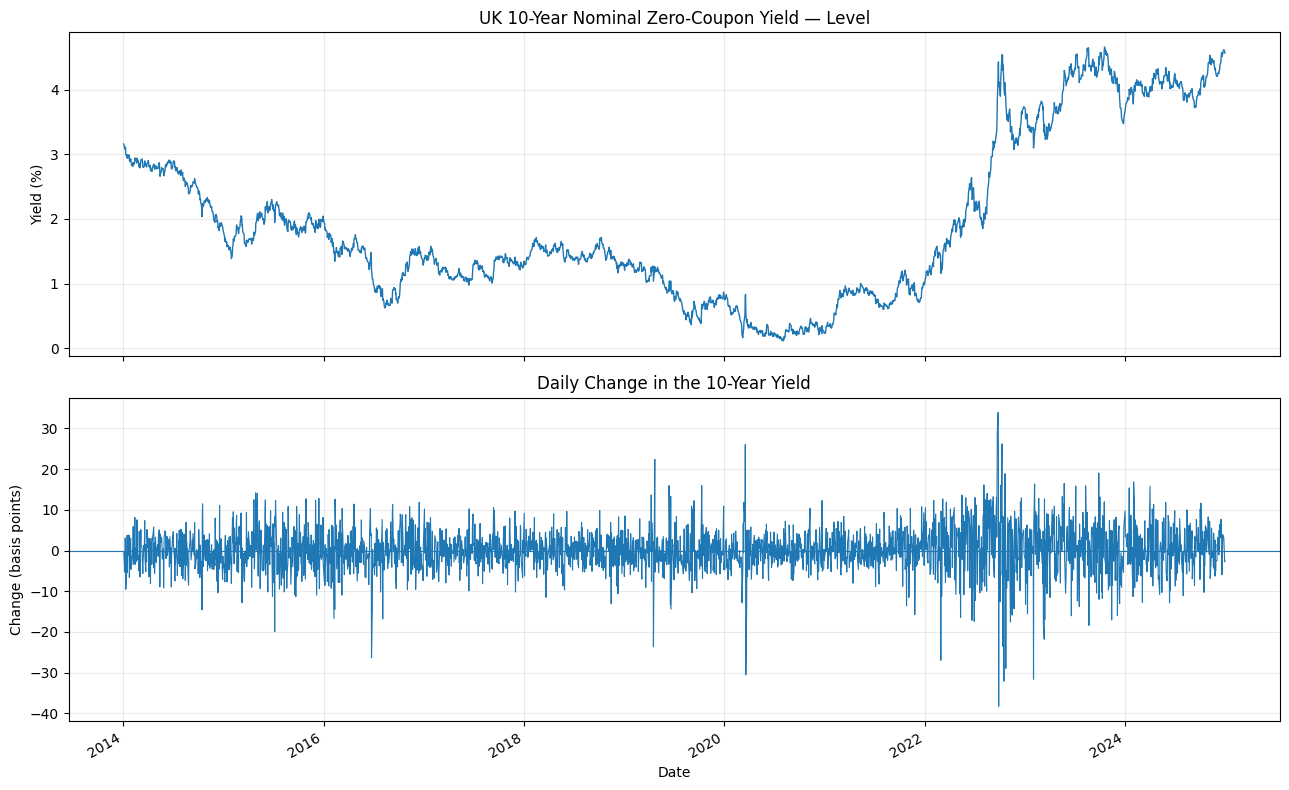

In [18]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(13, 8),
    sharex=True
)

axes[0].plot(
    analysis_data["date"],
    analysis_data["yield_10y"],
    linewidth=1
)
axes[0].set_title("UK 10-Year Nominal Zero-Coupon Yield — Level")
axes[0].set_ylabel("Yield (%)")
axes[0].grid(alpha=0.25)

axes[1].plot(
    analysis_data["date"],
    analysis_data["yield_change_bps"],
    linewidth=0.8
)
axes[1].axhline(0, linewidth=0.8)
axes[1].set_title("Daily Change in the 10-Year Yield")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Change (basis points)")
axes[1].grid(alpha=0.25)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Yield Level versus First Differences

- The yield level shows large and persistent changes over time. It falls substantially between 2014 and 2020–2021 before rising sharply from 2022 onwards. The series therefore does not appear to fluctuate around a constant mean, which provides an initial visual indication of non-stationarity.

- The first-difference series behaves differently. Daily yield changes fluctuate much more closely around zero and do not show the same long-term trend as the yield level. However, the size of the fluctuations is not constant through time. Larger movements are concentrated particularly around 2022–2023, suggesting time-varying variance and possible volatility clustering.

### Rolling mean and rolling standard deviation

Weak stationarity requires a constant mean and a covariance structure that depends on lag rather than calendar time. Constant variance is included because variance is the lag-zero covariance.

A rolling window does **not prove** stationarity. It is a local diagnostic showing whether the observed mean and spread appear to change through the sample.

A 60-observation window is used here, corresponding to roughly three trading months.

In [19]:
ROLLING_WINDOW = 60

analysis_data["level_roll_mean_60"] = (
    analysis_data["yield_10y"]
    .rolling(ROLLING_WINDOW)
    .mean()
)

analysis_data["level_roll_std_60"] = (
    analysis_data["yield_10y"]
    .rolling(ROLLING_WINDOW)
    .std()
)

analysis_data["change_roll_mean_60"] = (
    analysis_data["yield_change_bps"]
    .rolling(ROLLING_WINDOW)
    .mean()
)

analysis_data["change_roll_std_60"] = (
    analysis_data["yield_change_bps"]
    .rolling(ROLLING_WINDOW)
    .std()
)

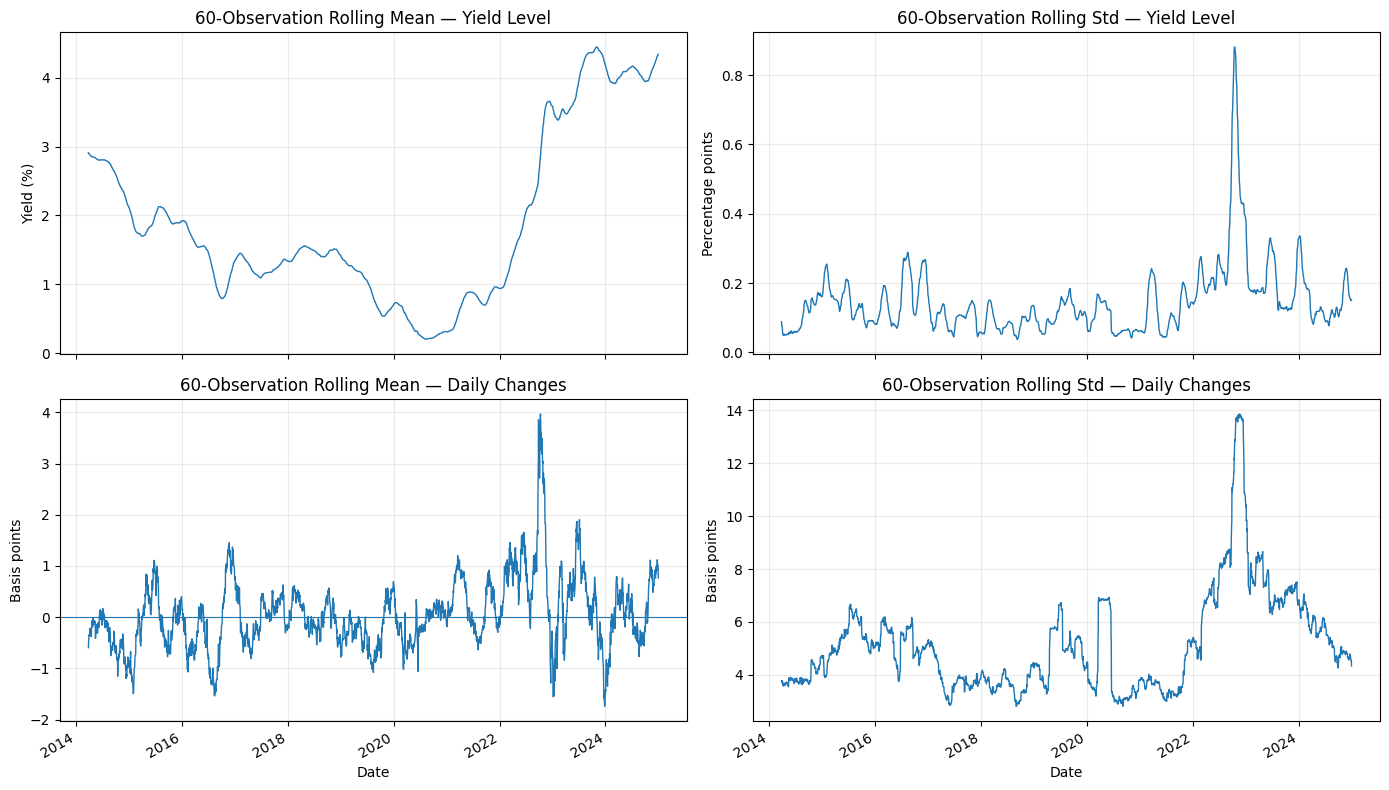

In [20]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 8),
    sharex=True
)

axes[0, 0].plot(
    analysis_data["date"],
    analysis_data["level_roll_mean_60"],
    linewidth=1
)
axes[0, 0].set_title("60-Observation Rolling Mean — Yield Level")
axes[0, 0].set_ylabel("Yield (%)")
axes[0, 0].grid(alpha=0.25)

axes[0, 1].plot(
    analysis_data["date"],
    analysis_data["level_roll_std_60"],
    linewidth=1
)
axes[0, 1].set_title("60-Observation Rolling Std — Yield Level")
axes[0, 1].set_ylabel("Percentage points")
axes[0, 1].grid(alpha=0.25)

axes[1, 0].plot(
    analysis_data["date"],
    analysis_data["change_roll_mean_60"],
    linewidth=1
)
axes[1, 0].axhline(0, linewidth=0.8)
axes[1, 0].set_title("60-Observation Rolling Mean — Daily Changes")
axes[1, 0].set_xlabel("Date")
axes[1, 0].set_ylabel("Basis points")
axes[1, 0].grid(alpha=0.25)

axes[1, 1].plot(
    analysis_data["date"],
    analysis_data["change_roll_std_60"],
    linewidth=1
)
axes[1, 1].set_title("60-Observation Rolling Std — Daily Changes")
axes[1, 1].set_xlabel("Date")
axes[1, 1].set_ylabel("Basis points")
axes[1, 1].grid(alpha=0.25)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Rolling Mean and Rolling Standard Deviation

The rolling statistics reinforce the difference between the yield level and its first differences. The 60-observation rolling mean of the yield level changes substantially across the sample, falling from around 3% in 2014 to below 0.5% around 2020–2021 before rising above 4% after 2022. Its rolling standard deviation also varies considerably, with a particularly large increase during 2022. These patterns are inconsistent with a constant mean and variance.

The daily yield changes behave differently. Their rolling mean remains much closer to zero throughout the sample, suggesting that differencing removes much of the long-run movement in the level series. However, the rolling standard deviation is clearly not constant. It is generally around 3–7 basis points before 2022 but rises sharply to almost 14 basis points during the 2022–2023 period.

Therefore, the first-difference series appears substantially more stable in its mean than the yield level, but its variance remains time-varying. Formal ADF and KPSS tests are required next to assess stationarity more systematically.

### Important distinction: unit-root stationarity versus variance stability

ADF and KPSS mainly address persistence in the **level/mean structure** of a series.

A series can reject a unit-root null and still have a variance that changes through time. Therefore:

- stationarity tests and
- rolling-volatility diagnostics

answer related but different questions.

This distinction is important for daily yield changes because periods of unusually large movements may indicate heteroskedasticity even when first differences are much more stable in mean than the yield level.

## Part II: Formal stationarity tests

### Augmented Dickey-Fuller and KPSS tests

The two tests have complementary null hypotheses.

#### ADF

- $H_0$: the series contains a unit root.
- $H_1$: the series does not contain a unit root under the specified deterministic terms.
- A small p-value provides evidence against the unit-root null.

#### KPSS

For `regression="c"`:

- $H_0$: the series is stationary around a constant level.
- $H_1$: the series is not level-stationary.

For `regression="ct"`:

- $H_0$: the series is stationary around a deterministic trend.
- $H_1$: the series is not trend-stationary.

Using both tests reduces the risk of drawing a conclusion from only one null hypothesis.

### Helper functions for reproducible test output

The functions below return tidy tables rather than only printing isolated p-values. Critical values, lag choices and sample sizes are retained for later reference.

In [21]:
def run_adf(series, name, regression="c"):
    x = pd.Series(series).dropna().astype(float)

    result = adfuller(
        x,
        regression=regression,
        autolag="AIC"
    )

    statistic, p_value, used_lag, n_obs, critical_values = result[:5]

    return {
        "series": name,
        "test": "ADF",
        "regression": regression,
        "statistic": statistic,
        "p_value": p_value,
        "lags": used_lag,
        "n_obs": n_obs,
        "critical_1pct": critical_values["1%"],
        "critical_5pct": critical_values["5%"],
        "critical_10pct": critical_values["10%"],
        "decision_5pct": (
            "Reject unit-root null"
            if p_value < 0.05
            else "Fail to reject unit-root null"
        ),
    }


def run_kpss(series, name, regression="c"):
    x = pd.Series(series).dropna().astype(float)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", InterpolationWarning)

        statistic, p_value, used_lags, critical_values = kpss(
            x,
            regression=regression,
            nlags="auto"
        )

    return {
        "series": name,
        "test": "KPSS",
        "regression": regression,
        "statistic": statistic,
        "p_value": p_value,
        "lags": used_lags,
        "n_obs": len(x),
        "critical_1pct": critical_values["1%"],
        "critical_5pct": critical_values["5%"],
        "critical_10pct": critical_values["10%"],
        "decision_5pct": (
            "Reject stationarity null"
            if p_value < 0.05
            else "Fail to reject stationarity null"
        ),
    }

### Primary tests: stationarity around a constant

The first comparison applies the standard constant-only specification to both the yield level and the daily change series.

In [22]:
primary_results = pd.DataFrame([
    run_adf(
        analysis_data["yield_10y"],
        "10Y yield level",
        regression="c"
    ),
    run_kpss(
        analysis_data["yield_10y"],
        "10Y yield level",
        regression="c"
    ),
    run_adf(
        analysis_data["yield_change_bps"],
        "Daily yield change (bps)",
        regression="c"
    ),
    run_kpss(
        analysis_data["yield_change_bps"],
        "Daily yield change (bps)",
        regression="c"
    ),
])

primary_results

,series,test,regression,statistic,p_value,lags,n_obs,critical_1pct,critical_5pct,critical_10pct,decision_5pct
0,10Y yield level,ADF,c,-0.382381,0.912999,0,2778,-3.432706,-2.862581,-2.567324,Fail to reject unit-root null
1,10Y yield level,KPSS,c,2.806202,0.010000,31,2779,0.739000,0.463000,0.347000,Reject stationarity null
2,Daily yield change (bps),ADF,c,-52.787279,0.000000,0,2777,-3.432707,-2.862581,-2.567324,Reject unit-root null
3,Daily yield change (bps),KPSS,c,0.626656,0.020213,2,2778,0.739000,0.463000,0.347000,Reject stationarity null


### ADF and KPSS Stationarity Tests

- **ADF — Yield level:** The p-value is 0.913, so the unit-root null is not rejected. This indicates that the 10-year yield level is non-stationary.

- **KPSS — Yield level:** The p-value is 0.010, so the stationarity null is rejected. This also provides evidence that the yield level is non-stationary.

- **ADF — Daily yield changes:** The p-value is effectively 0, so the unit-root null is strongly rejected. This indicates that differencing removes the strong unit-root behaviour present in the yield level.

- **KPSS — Daily yield changes:** The p-value is 0.020, so the stationarity null is rejected at the 5% level. This creates mixed evidence for the differenced series and suggests that some instability remains despite the removal of the long-term trend.

Overall, both tests agree that the yield level is non-stationary, while the first-difference series is substantially more stable but does not satisfy both stationarity tests at the 5% level.

### Trend-stationarity sensitivity check for the yield level

The full yield level visibly moves through long periods of falling and rising rates. A second specification therefore allows for a deterministic time trend.

This is a **robustness check**, not an instruction to fit a trend model for forecasting.

In [23]:
trend_results = pd.DataFrame([
    run_adf(
        analysis_data["yield_10y"],
        "10Y yield level",
        regression="ct"
    ),
    run_kpss(
        analysis_data["yield_10y"],
        "10Y yield level",
        regression="ct"
    ),
])

trend_results

,series,test,regression,statistic,p_value,lags,n_obs,critical_1pct,critical_5pct,critical_10pct,decision_5pct
0,10Y yield level,ADF,ct,-1.429584,0.852018,0,2778,-3.962033,-3.412072,-3.127981,Fail to reject unit-root null
1,10Y yield level,KPSS,ct,1.799304,0.010000,31,2779,0.216000,0.146000,0.119000,Reject stationarity null


### Trend-Stationarity Sensitivity Check

- **ADF with trend — Yield level:** The p-value is 0.852, so the unit-root null is not rejected even after allowing for a deterministic trend. This indicates that the yield level remains non-stationary.

- **KPSS with trend — Yield level:** The p-value is 0.010, so the trend-stationarity null is rejected. This also indicates that the yield level is not stationary around a deterministic trend.

Overall, allowing for a deterministic trend does not change the conclusion: the 10-year yield level remains clearly non-stationary.

### Joint ADF–KPSS Interpretation

ADF and KPSS have opposite null hypotheses, so they are interpreted together:

- **ADF rejects + KPSS does not reject:** evidence supports stationarity.
- **ADF does not reject + KPSS rejects:** evidence supports non-stationarity.
- **Both reject or both fail to reject:** the evidence is mixed.

For this dataset, both tests support non-stationarity in the yield level, while the daily yield changes give mixed evidence.

In [24]:
def joint_stationarity_label(adf_p, kpss_p, alpha=0.05):
    adf_rejects = adf_p < alpha
    kpss_rejects = kpss_p < alpha

    if adf_rejects and not kpss_rejects:
        return "Evidence consistent with stationarity"

    if (not adf_rejects) and kpss_rejects:
        return "Evidence consistent with non-stationarity"

    return "Mixed / inconclusive evidence"


joint_rows = []

for series_name in [
    "10Y yield level",
    "Daily yield change (bps)"
]:
    subset = primary_results[
        primary_results["series"] == series_name
    ]

    adf_p = subset.loc[
        subset["test"] == "ADF",
        "p_value"
    ].iloc[0]

    kpss_p = subset.loc[
        subset["test"] == "KPSS",
        "p_value"
    ].iloc[0]

    joint_rows.append({
        "series": series_name,
        "ADF_p_value": adf_p,
        "KPSS_p_value": kpss_p,
        "joint_5pct_interpretation": joint_stationarity_label(
            adf_p,
            kpss_p
        ),
    })

joint_stationarity = pd.DataFrame(joint_rows)
joint_stationarity

,series,ADF_p_value,KPSS_p_value,joint_5pct_interpretation
0,10Y yield level,0.912999,0.010000,Evidence consistent with non-stationarity
1,Daily yield change (bps),0.000000,0.020213,Mixed / inconclusive evidence


### Joint Stationarity Result

- **10-year yield level:** ADF does not reject a unit root (`p = 0.913`) and KPSS rejects stationarity (`p = 0.010`). The two tests therefore agree that the yield level is non-stationary.

- **Daily yield changes:** ADF strongly rejects a unit root (`p < 0.001`), while KPSS also rejects stationarity (`p = 0.020`). The evidence is therefore mixed. Differencing removes the strong persistence in the yield level, but some instability remains in the differenced series.

## Part III: Autocorrelation structure

### ACF and PACF

The **autocorrelation function (ACF)** measures correlation between a series and lagged versions of itself.

The **partial autocorrelation function (PACF)** measures the correlation at a given lag after accounting for the linear influence of the shorter lags.


- A slowly decaying ACF in the **yield level** is treated as evidence of strong persistence, not as proof of a particular model.
- ACF/PACF of the **daily changes** show whether linear serial dependence remains after differencing.
- Bars outside the confidence bands indicate sample correlations that are statistically distinguishable from zero under the plotting approximation.

### ACF and PACF of the yield level

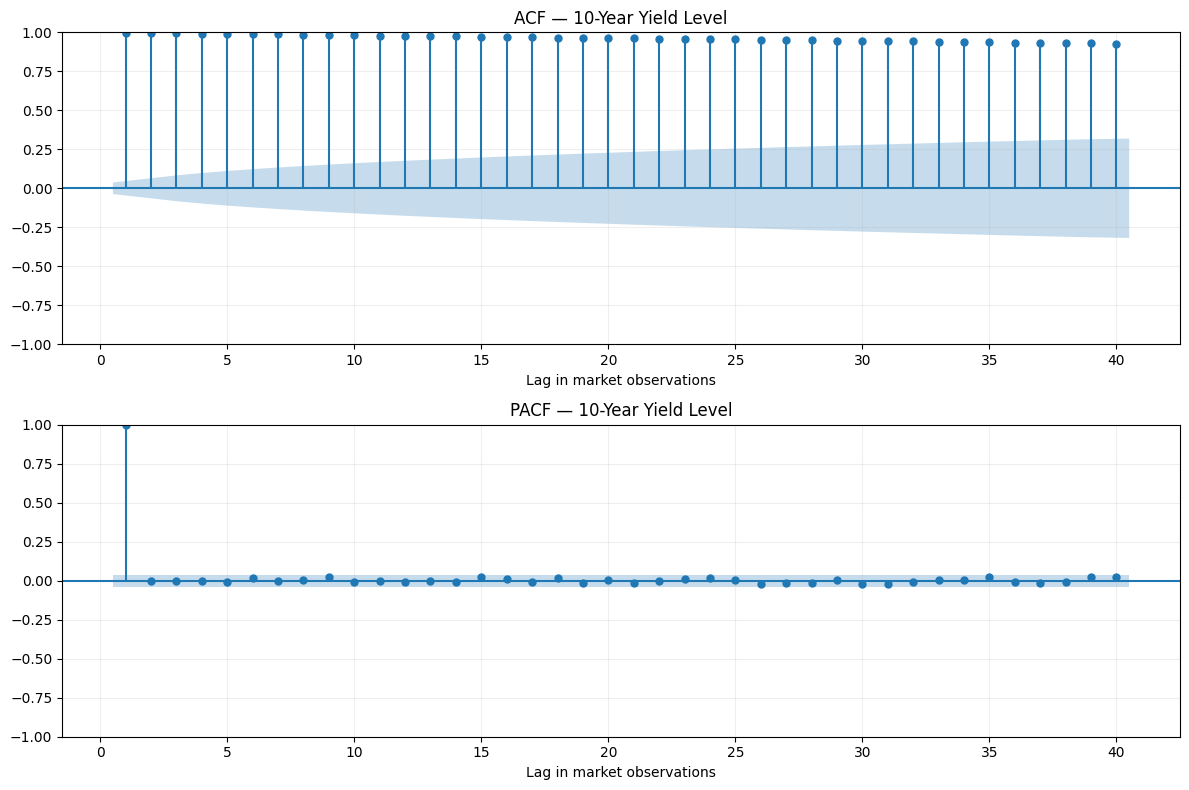

In [25]:
MAX_LAGS = 40

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 8)
)

plot_acf(
    analysis_data["yield_10y"].dropna(),
    lags=MAX_LAGS,
    zero=False,
    ax=axes[0]
)
axes[0].set_title("ACF — 10-Year Yield Level")
axes[0].set_xlabel("Lag in market observations")
axes[0].grid(alpha=0.2)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    plot_pacf(
        analysis_data["yield_10y"].dropna(),
        lags=MAX_LAGS,
        zero=False,
        method="ywm",
        ax=axes[1]
    )

axes[1].set_title("PACF — 10-Year Yield Level")
axes[1].set_xlabel("Lag in market observations")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

- **ACF:** Autocorrelation remains extremely high across all 40 lags and decays only very slowly, indicating very strong persistence in the yield level.
- **PACF:** There is one dominant spike at lag 1, while most later lags are close to zero.

This pattern is consistent with the earlier stationarity tests and provides further evidence that the yield level is highly persistent and non-stationary.

### ACF and PACF of daily yield changes

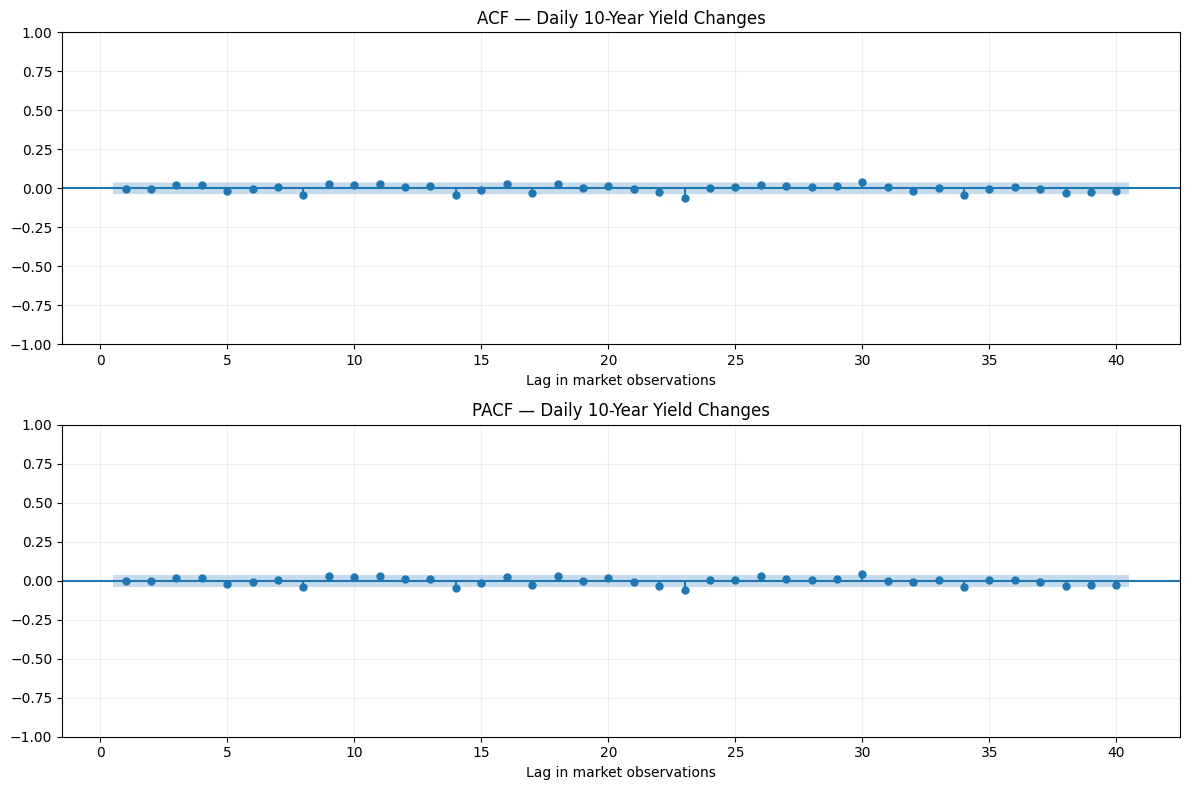

In [26]:
change_series = analysis_data["yield_change_bps"].dropna()

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 8)
)

plot_acf(
    change_series,
    lags=MAX_LAGS,
    zero=False,
    ax=axes[0]
)
axes[0].set_title("ACF — Daily 10-Year Yield Changes")
axes[0].set_xlabel("Lag in market observations")
axes[0].grid(alpha=0.2)

plot_pacf(
    change_series,
    lags=MAX_LAGS,
    zero=False,
    method="ywm",
    ax=axes[1]
)
axes[1].set_title("PACF — Daily 10-Year Yield Changes")
axes[1].set_xlabel("Lag in market observations")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

- **ACF:** Most autocorrelations are close to zero, with only a few small spikes outside the confidence band. This suggests little linear dependence between daily yield changes across lags.
- **PACF:** The partial autocorrelations are also generally small, with no dominant lag structure.

The differenced series shows much weaker persistence than the yield level, supporting the view that first differencing removes most of the serial dependence in the level series.

## Part IV: Structural breaks and crisis dates

### Why structural breaks matter

A long financial time series can move through different policy and market regimes. A structural change can make a full-sample stationarity test harder to interpret because the mean or trend may shift at a particular date.

Two complementary checks are used:

1. a **Zivot–Andrews break-aware unit-root diagnostic**, which allows one endogenously selected structural break;
   
2. explicit inspection of the two central 2022 LDI-crisis dates established in Notebook 01.

The estimated break date is a statistical diagnostic. It is **not** automatically an economic event date and does not establish causality.

### Zivot–Andrews break-aware unit-root diagnostic

The test is applied first to the yield level with a constant and deterministic trend (`regression="ct"`).

A rejection of the unit-root null provides evidence against unit-root behaviour when one endogenous break is allowed.

Only a **single** break is considered by this test, so it cannot describe every regime change in an eleven-year financial sample.

In [27]:
def run_zivot_andrews(
    series,
    dates,
    name,
    regression="ct"
):
    x = pd.Series(series).reset_index(drop=True)
    date_series = pd.Series(dates).reset_index(drop=True)

    valid = x.notna() & date_series.notna()

    x = x.loc[valid].astype(float).reset_index(drop=True)
    date_series = pd.to_datetime(
        date_series.loc[valid]
    ).reset_index(drop=True)

    statistic, p_value, critical_values, base_lag, break_index = (
        zivot_andrews(
            x,
            regression=regression,
            autolag="AIC"
        )
    )

    break_date = date_series.iloc[int(break_index)]

    return {
        "series": name,
        "regression": regression,
        "statistic": statistic,
        "p_value": p_value,
        "base_lag": base_lag,
        "break_index": int(break_index),
        "estimated_break_date": break_date,
        "critical_1pct": critical_values["1%"],
        "critical_5pct": critical_values["5%"],
        "critical_10pct": critical_values["10%"],
        "decision_5pct": (
            "Reject unit-root null"
            if p_value < 0.05
            else "Fail to reject unit-root null"
        ),
    }


za_level = run_zivot_andrews(
    analysis_data["yield_10y"],
    analysis_data["date"],
    "10Y yield level",
    regression="ct"
)

za_level_table = pd.DataFrame([za_level])
za_level_table

,series,regression,statistic,p_value,base_lag,break_index,estimated_break_date,critical_1pct,critical_5pct,critical_10pct,decision_5pct
0,10Y yield level,ct,-4.106038,0.433644,0,2013,2021-12-15,-5.57556,-5.07332,-4.82668,Fail to reject unit-root null


### Zivot–Andrews Structural-Break Test

The Zivot–Andrews test identifies **15 December 2021** as the estimated structural break in the yield level. However, the test statistic of **-4.106** is not more negative than the 5% critical value of **-5.073**, and the p-value is **0.434**.

Therefore, the unit-root null is not rejected. Even after allowing for one endogenous structural break, the 10-year yield level still appears non-stationary.

### Mark statistical and economic break dates on the full sample

The central LDI dates are:

- **23 September 2022:** UK mini-budget;
- **28 September 2022:** Bank of England temporary gilt-purchase intervention.

These dates are fixed economic-event dates. The Zivot–Andrews date is estimated from the statistical behaviour of the full sample.

Agreement between them would be interesting, but disagreement would not invalidate either quantity because they answer different questions.

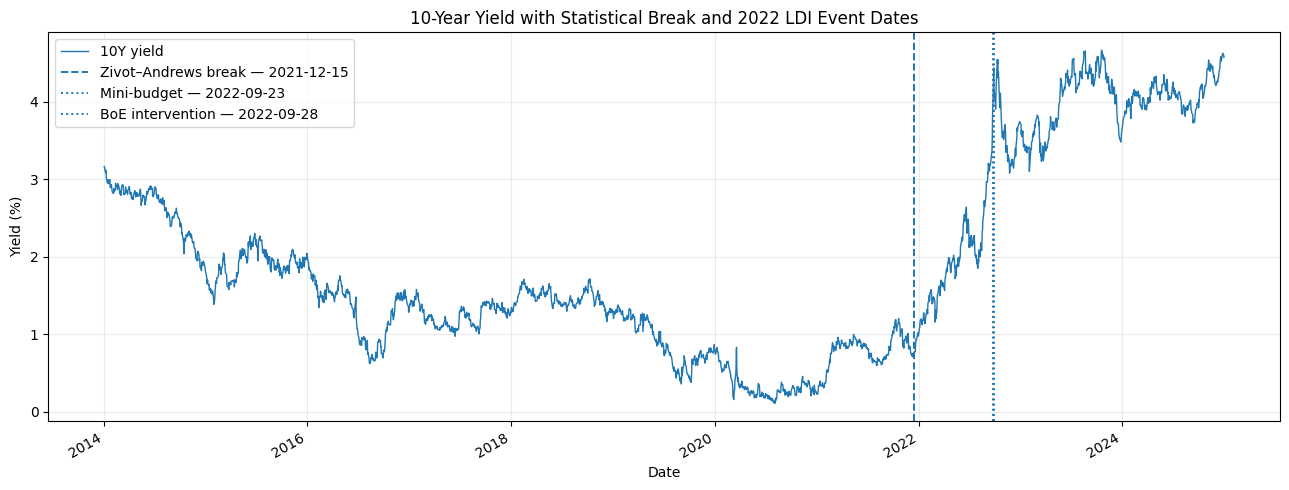

In [28]:
EVENTS = {
    "Mini-budget": pd.Timestamp("2022-09-23"),
    "BoE intervention": pd.Timestamp("2022-09-28"),
}

za_break_date = pd.Timestamp(
    za_level["estimated_break_date"]
)

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(
    analysis_data["date"],
    analysis_data["yield_10y"],
    linewidth=1,
    label="10Y yield"
)

ax.axvline(
    za_break_date,
    linestyle="--",
    linewidth=1.4,
    label=f"Zivot–Andrews break — {za_break_date.date()}"
)

for label, event_date in EVENTS.items():
    ax.axvline(
        event_date,
        linestyle=":",
        linewidth=1.4,
        label=f"{label} — {event_date.date()}"
    )

ax.set_title(
    "10-Year Yield with Statistical Break and 2022 LDI Event Dates"
)
ax.set_xlabel("Date")
ax.set_ylabel("Yield (%)")
ax.grid(alpha=0.25)
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Statistical and Economic Event Dates

The Zivot–Andrews procedure selects **15 December 2021** as its estimated break date, while the key LDI-crisis events occurred on **23 September 2022** (mini-budget) and **28 September 2022** (BoE intervention).

The estimated break date should not be interpreted as a confirmed structural break because the Zivot–Andrews unit-root null was not rejected. The comparison is included to distinguish the statistically selected date from the known economic-event dates.

### Event-window diagnostics around the LDI crisis

For each event, the table reports:

- the event-day yield and daily change;
- the mean yield in the preceding and following market observations;
- the mean daily change before and after;
- the standard deviation of daily changes before and after;
- the largest absolute daily move in each window.

The windows are descriptive. They overlap with nearby events and therefore should not be interpreted as causal estimates of the mini-budget or the BoE intervention.

In [40]:
def event_window_summary(
    data,
    event_name,
    event_date,
    n_obs=10
):
    event_date = pd.Timestamp(event_date)

    matches = data.index[
        data["date"] == event_date
    ].tolist()

    if not matches:
        raise ValueError(
            f"{event_name}: {event_date.date()} "
            "is not an observed market date in the dataset."
        )

    event_idx = matches[0]

    pre = data.iloc[
        max(0, event_idx - n_obs):event_idx
    ].copy()

    event = data.iloc[event_idx]

    post = data.iloc[
        event_idx + 1:event_idx + 1 + n_obs
    ].copy()

    return {
        "event": event_name,
        "event_date": event_date.date(),
        "event_yield_percent": event["yield_10y"],
        "event_change_bps": event["yield_change_bps"],
        "pre_n": len(pre),
        "post_n": len(post),
        "pre_mean_yield": pre["yield_10y"].mean(),
        "post_mean_yield": post["yield_10y"].mean(),
        "pre_mean_change_bps": pre["yield_change_bps"].mean(),
        "post_mean_change_bps": post["yield_change_bps"].mean(),
        "pre_std_change_bps": pre["yield_change_bps"].std(),
        "post_std_change_bps": post["yield_change_bps"].std(),
        "pre_max_abs_change_bps": pre["yield_change_bps"].abs().max(),
        "post_max_abs_change_bps": post["yield_change_bps"].abs().max(),
    }


event_window_results = pd.DataFrame([
    event_window_summary(
        analysis_data,
        "Mini-budget",
        EVENTS["Mini-budget"],
        n_obs=10
    ),
    event_window_summary(
        analysis_data,
        "BoE intervention",
        EVENTS["BoE intervention"],
        n_obs=10
    ),
])

event_window_results

,event,event_date,event_yield_percent,event_change_bps,pre_n,post_n,pre_mean_yield,post_mean_yield,pre_mean_change_bps,post_mean_change_bps,pre_std_change_bps,post_std_change_bps,pre_max_abs_change_bps,post_max_abs_change_bps
0,Mini-budget,2022-09-23,3.8426,29.10,10,10,3.25061,4.13195,4.784,4.40,8.139864,20.673311,18.21,38.24
1,BoE intervention,2022-09-28,4.0517,-38.24,10,10,3.54804,4.22191,13.276,4.87,12.771454,12.047729,33.91,26.19


- **Mini-budget (23 September 2022):** The yield rose by **29.10 bps** on the event day. The 10-observation post-event window had substantially higher volatility than the pre-event window, with the standard deviation increasing from **8.14 to 20.67 bps**.

- **BoE intervention (28 September 2022):** The yield fell by **38.24 bps** on the event day, the largest movement in these event windows. Average daily changes were smaller after the intervention than before it, while volatility remained elevated.

These windows overlap because the two events occurred only a few market days apart. The results therefore describe movements around the crisis dates but should not be interpreted as evidence that either event caused the observed changes.

### Zoom into the 2022 crisis window

The level and change series are displayed together around September–October 2022.

This makes it possible to distinguish:

- a large change in the **level** of yields;
- exceptionally large positive or negative **daily movements**;
- persistence after the immediate intervention date.

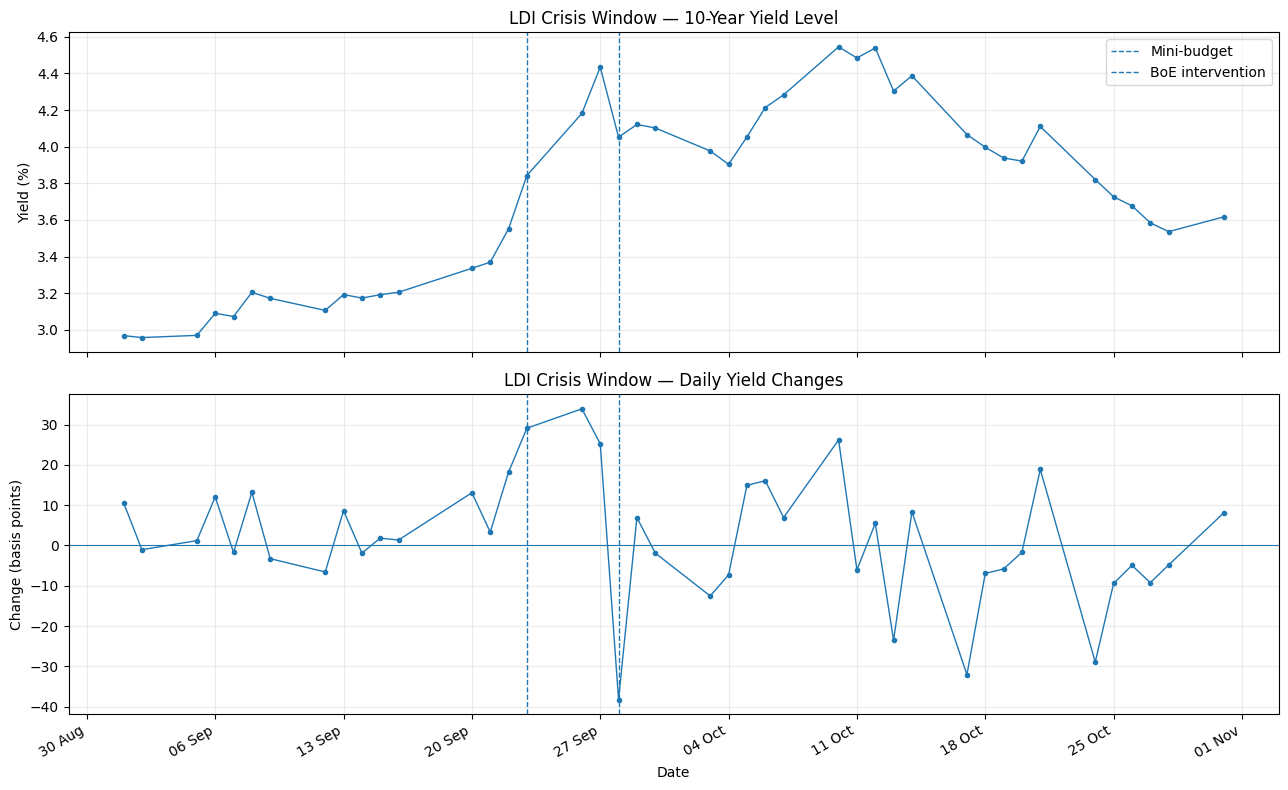

In [33]:
crisis = analysis_data[
    analysis_data["date"].between(
        "2022-09-01",
        "2022-10-31"
    )
].copy()

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(13, 8),
    sharex=True
)

axes[0].plot(
    crisis["date"],
    crisis["yield_10y"],
    marker="o",
    markersize=3,
    linewidth=1
)
axes[0].set_title("LDI Crisis Window — 10-Year Yield Level")
axes[0].set_ylabel("Yield (%)")
axes[0].grid(alpha=0.25)

axes[1].plot(
    crisis["date"],
    crisis["yield_change_bps"],
    marker="o",
    markersize=3,
    linewidth=1
)
axes[1].axhline(0, linewidth=0.8)
axes[1].set_title("LDI Crisis Window — Daily Yield Changes")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Change (basis points)")
axes[1].grid(alpha=0.25)

for label, event_date in EVENTS.items():
    for ax in axes:
        ax.axvline(
            event_date,
            linestyle="--",
            linewidth=1,
            label=label
        )

handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
axes[0].legend(
    by_label.values(),
    by_label.keys()
)

axes[1].xaxis.set_major_locator(
    mdates.WeekdayLocator(interval=1)
)
axes[1].xaxis.set_major_formatter(
    mdates.DateFormatter("%d %b")
)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### LDI Crisis Window

The crisis window shows a sharp increase in the 10-year yield around the September 2022 events. The yield rose from roughly 3.4% before the mini-budget to above 4.4% by late September, before falling sharply on 28 September following the BoE intervention.

Daily yield changes were also unusually large during this period, including gains above 30 basis points and the **-38.24 bps** movement on 28 September. Large positive and negative changes continued through October, showing that volatility remained elevated after the initial crisis events.

## Part V: Summary

### Key Findings

- The 10-year yield level is strongly persistent and non-stationary under the ADF and KPSS diagnostics.
- First differencing removes most of the persistence, although ADF and KPSS provide mixed evidence for the daily-change series.
- ACF and PACF indicate little linear serial dependence in daily yield changes.
- The variance of daily changes is clearly time-varying, with unusually large movements concentrated around the 2022 LDI crisis period.
- Allowing for one endogenous break does not overturn the non-stationarity conclusion for the yield level.

### What this notebook does **not** establish

Several boundaries are important.

1. **ADF rejection does not prove white noise.**  
   A stationary series may still contain serial dependence.

2. **Stationarity does not imply constant volatility in practice.**  
   Daily changes can be stationary in their mean structure while still displaying heteroskedasticity or volatility clustering.

3. **ACF/PACF significance does not by itself select a final model.**  
   Model identification, estimation and residual checking belong in the next notebook.

4. **A statistical break is not automatically an economic cause.**  
   The Zivot–Andrews break is selected from the data. The mini-budget and BoE intervention dates are externally known events.

5. **The event-window comparison is descriptive.**  
   Overlapping policy and market developments prevent a simple before/after table from establishing causal effects.

### save diagnostic tables

In [39]:
OUTPUT_DIR = Path("outputs") / "eda"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

primary_results.to_csv(
    OUTPUT_DIR / "adf_kpss_primary_results.csv",
    index=False
)

trend_results.to_csv(
    OUTPUT_DIR / "adf_kpss_trend_sensitivity.csv",
    index=False
)

joint_stationarity.to_csv(
    OUTPUT_DIR / "stationarity_joint_summary.csv",
    index=False
)

za_level_table.to_csv(
    OUTPUT_DIR / "zivot_andrews_yield_level.csv",
    index=False
)

event_window_results.to_csv(
    OUTPUT_DIR / "ldi_event_window_summary.csv",
    index=False
)

print(f"Saved diagnostic tables to: {OUTPUT_DIR.resolve()}")

Saved diagnostic tables to: /Users/qp252008/Downloads/Dissertation/outputs/eda


## References:

- Marco Peixeiro, *Time Series Forecasting in Python*, Chapters 3–5.
- `TSnotes: QMUL24`, especially the discussion of first differencing, weak stationarity and heteroskedasticity.
- `statsmodels` implementations of ADF, KPSS, ACF, PACF and Zivot–Andrews are used for the statistical diagnostics.